# Predicting outcomes from ICU time series

This tutorial trains, evaluates and interprets prediction models on longitudinal ICU data.
We predict in-hospital mortality from the first 48 hours of an ICU stay in the PhysioNet 2012 challenge {cite}`silva2012predicting` {cite}`goldberger2000physiobank` and compare gradient boosting on summaries with two deep learning models of the raw time series.
We then check how well calibrated, certain and fair the predictions are and which variables they rely on.
Finally, we predict sepsis hour by hour in the PhysioNet 2019 challenge {cite}`reyna2020early`.
Every step is set up so that the reported performance is the one we would expect on new patients.

:::{note}
The deep learning models need PyTorch, which `pip install 'ehrapy[ml]'` installs.
SAITS additionally needs {doc}`PyPOTS <pypots:index>` (`pip install pypots`).
:::

## Environment setup

In [1]:
import warnings

warnings.filterwarnings("ignore")

import ehrapy as ep
import ehrdata as ed
import numpy as np
import pandas as pd
import torch
from pypots.nn.modules.saits import BackboneSAITS

ep.settings.verbosity = "error"

In [2]:
%matplotlib inline

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
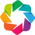

In [3]:
import holoviews as hv

hv.extension("bokeh")

## In-hospital mortality

### Data

The PhysioNet 2012 data holds 37 variables recorded hourly over the first 48 hours of 11,988 ICU stays.
The outcome `In-hospital_death` and static information such as age and sex (`Gender`) are in `obs`.
We derive age groups for the subgroup analysis below.

In [4]:
edata = ed.dt.physionet2012()
edata.obs["age_group"] = pd.cut(edata.obs["Age"], [0, 65, 80, np.inf], right=False, labels=["15-64", "65-79", "80-90"])
edata

EHRData object with n_obs × n_vars × n_t = 11988 × 37 × 48
    obs: 'set', 'Age', 'Gender', 'Height', 'ICUType', 'SAPS-I', 'SOFA', 'Length_of_stay', 'Survival', 'In-hospital_death', 'age_group'
    var: 'Parameter'
    tem: '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47'
    shape of .X: (11988, 37, 48)

:::{warning}
`Length_of_stay` and `Survival` are only known after the stay, so they must never become features.
Any variable recorded after the time of prediction leaks the outcome into the model and inflates its performance.
:::

### Patient-level split

{func}`~ehrapy.ml.split` assigns patients to a `train`, a `tuning` and a `held_out` set.
All observations of a patient end up in the same set, so a model is never evaluated on a patient it has seen during training.
Here every observation is one patient; with several stays per patient, pass their identifier as `patient_key`.
Stratifying on the outcome keeps the mortality of about 14% in every set.

In [5]:
ep.ml.split(edata, stratify="In-hospital_death")
pd.crosstab(edata.obs["split"], edata.obs["In-hospital_death"], normalize="index")

In-hospital_death,0,1
split,,
train,0.857602,0.142398
tuning,0.857620,0.142380
held_out,0.857620,0.142380


:::{warning}
Split before imputing, normalizing or selecting variables.
Any statistic computed on all patients leaks information from the held-out patients into the model, which is why {func}`~ehrapy.ml.fit` fits all preprocessing on the training patients only.
:::

### Prediction task

A {class}`~ehrapy.ml.Task` defines what is predicted and from which timepoints.
We predict at hour 48 from a 42-hour observation window that ends 6 hours earlier.
The gap guards against leakage from the last hours before the prediction, whose measurements are often not available yet in practice and can already reflect the clinical decisions the model should anticipate.

In [6]:
task = ep.ml.Task("In-hospital_death", prediction_time=48, observation_window=42, gap=6)

### Gradient boosting on summaries

{func}`~ehrapy.ml.fit` summarizes every variable over the observation window with {func}`~ehrapy.preprocessing.summarize_measurements`.
Next to the minimum, maximum, mean and last value, `count` captures how often a variable was measured, `std` its variability and `slope` its trend.
The median imputation and standardization of these features are fit on the training patients only.

In [7]:
statistics = ["min", "max", "mean", "last", "count", "std", "slope"]
gradient_boosting = ep.ml.fit(edata, task, model="gradient_boosting", obs_keys=["Age", "Gender"], statistics=statistics)
ep.ml.predict(edata, gradient_boosting, key_added="gradient_boosting")

:::{warning}
How often a variable is measured reflects how closely clinicians monitored a patient, which depends on their suspicion and on local practice.
A model that relies on `count` learns care patterns along with physiology and can fail where monitoring differs.
:::

### Deep learning on the raw time series

The GRU reads the hourly values of the observation window directly, together with whether every value was observed and the time since its last observation.
Like every deep learning model in ehrapy, it stops training once its loss on the tuning set stops improving, which keeps the held-out set untouched until the evaluation.

In [8]:
gru = ep.ml.fit(edata, task, model="gru", obs_keys=["Age", "Gender"])
ep.ml.predict(edata, gru, key_added="gru")

SAITS {cite}`du2023saits` is a self-attention model for partially observed time series from PyPOTS.
{func}`~ehrapy.ml.fit` accepts any PyTorch module that maps the values, whether they were observed, the time since their last observation and the static covariates to an embedding.
We wrap the SAITS backbone as such a module, with missing values set to zero and the diagonal of the attention masked as in PyPOTS.
Its embedding is the estimate of every value of the window that the SAITS classifier of PyPOTS also feeds to its output layer.

In [9]:
class SAITS(torch.nn.Module):
    def __init__(self, n_steps: int, n_features: int, d_model: int = 32, n_heads: int = 4):
        super().__init__()
        self.backbone = BackboneSAITS(
            n_steps,
            n_features,
            n_layers=1,
            d_model=d_model,
            n_heads=n_heads,
            d_k=d_model // n_heads,
            d_v=d_model // n_heads,
            d_ffn=2 * d_model,
            dropout=0.1,
            attn_dropout=0.1,
        )
        self.register_buffer("diagonal_mask", 1 - torch.eye(n_steps)[None])

    def forward(self, values, mask, time_since_observed, static):
        return self.backbone(values * mask, mask, self.diagonal_mask)[2].flatten(1)

SAITS then gets the same split, observation window, standardization and early stopping as the GRU, which makes the comparison fair.

:::{note}
To keep this tutorial fast on a CPU, we fit SAITS on 3,000 of the 8,392 training patients, which puts it at a disadvantage.
With all training patients, it reached an AUROC of about 0.85, like the other two models.
:::

In [10]:
saits = ep.ml.fit(
    edata, task, model=SAITS(task.observation_window, edata.n_vars), obs_keys=["Age", "Gender"], max_train_obs=3000
)
ep.ml.predict(edata, saits, key_added="saits")

### Evaluation

{func}`~ehrapy.ml.evaluate` computes the metrics on the held-out patients with bootstrap confidence intervals.
It resamples patients rather than rows, so the intervals reflect how much the results vary between patients.
We use 200 bootstrap samples to keep this tutorial fast, while the default of 1,000 gives more stable intervals.

In [11]:
models = ["gradient_boosting", "gru", "saits"]
pd.concat({model: ep.ml.evaluate(edata, task, key=model, n_bootstrap=200) for model in models}, axis=1).round(3)

gradient_boosting                      gru           \
                                  value ci_lower ci_upper  value ci_lower   
metric                                                                      
auroc                             0.854    0.831    0.874  0.856    0.836   
auprc                             0.491    0.435    0.558  0.526    0.474   
brier                             0.096    0.087    0.105  0.091    0.083   
ece                               0.038    0.029    0.052  0.016    0.013   
calibration_intercept             0.326    0.170    0.495  0.077   -0.067   
calibration_slope                 0.792    0.698    0.874  1.024    0.922   
sensitivity                       0.266    0.217    0.320  0.273    0.219   
specificity                       0.968    0.960    0.976  0.977    0.969   
f1                                0.365    0.310    0.430  0.387    0.322   
positive_rate                     0.065    0.053    0.078  0.059    0.047   

                                saits                    
                      ci_upper  value ci_lower ci_upper  
metric                                                   
auroc                    0.875  0.825    0.806    0.850  
auprc                    0.592  0.443    0.392    0.511  
brier                    0.100  0.098    0.090    0.106  
ece                      0.032  0.021    0.016    0.037  
calibration_intercept    0.212  0.124   -0.017    0.259  
calibration_slope        1.133  0.863    0.779    0.977  
sensitivity              0.335  0.223    0.177    0.282  
specificity              0.984  0.975    0.968    0.982  
f1                       0.455  0.324    0.267    0.392  
positive_rate            0.073  0.053    0.042    0.065

Gradient boosting and the GRU both reach an AUROC of about 0.855 on the held-out patients with overlapping confidence intervals, so the GRU on the raw time series does not beat gradient boosting on well-chosen summaries here.
SAITS, fit on far fewer patients, falls slightly behind with an AUROC of 0.825.
At the default threshold of 0.5, all three flag only about 6% of patients and miss three of four deaths, so a threshold has to be chosen for the clinical use.

:::{admonition} Which model?
:class: tip
Start with gradient boosting on summaries that include `count`, `std` and `slope`: it is fast, needs no GPU and is hard to beat on cohorts of this size.
Deep learning models of the raw time series pay off with many more patients or long, irregularly sampled series.
:::

In [12]:
ep.pl.prediction_performance(edata, task, key="gradient_boosting")

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

:Layout
   .Overlay.I   :Overlay
      .Curve.I  :Curve   [False positive rate]   (True positive rate)
      .Curve.II :Curve   [False positive rate]   (True positive rate)
   .Overlay.II  :Overlay
      .Curve.I :Curve   [Recall]   (Precision)
      .HLine.I :HLine   [x,y]
   .Overlay.III :Overlay
      .Curve.I   :Curve   [Mean predicted probability]   (Observed frequency)
      .Scatter.I :Scatter   [x]   (y)
      .Curve.II  :Curve   [Mean predicted probability]   (Observed frequency)

The dashed line of the precision-recall curve is the mortality of the held-out patients, the AUPRC of a model that guesses.

### Calibration

A predicted risk of 30% should mean that 30 of 100 such patients die.
The calibration slope below 1 shows that the predicted risks of gradient boosting are too extreme, and the positive intercept that they underestimate the risk on average.
{func}`~ehrapy.ml.calibrate` fits Platt scaling on the tuning set, which the model was not fit on, since calibrating on the held-out set would leak it into the evaluation.
Platt scaling keeps the order of the predictions and therefore the AUROC.

In [13]:
calibrated = ep.ml.calibrate(edata, gradient_boosting, method="platt")
ep.ml.predict(edata, calibrated, key_added="calibrated")
calibration_metrics = ["auroc", "brier", "ece", "calibration_intercept", "calibration_slope"]
pd.concat(
    {
        key: ep.ml.evaluate(edata, task, key=key, n_bootstrap=200).loc[calibration_metrics]
        for key in ["gradient_boosting", "calibrated"]
    },
    axis=1,
).round(3)

gradient_boosting                   calibrated           \
                                  value ci_lower ci_upper      value ci_lower   
metric                                                                          
auroc                             0.854    0.831    0.874      0.854    0.831   
brier                             0.096    0.087    0.105      0.094    0.086   
ece                               0.038    0.029    0.052      0.019    0.014   
calibration_intercept             0.326    0.170    0.495      0.100   -0.038   
calibration_slope                 0.792    0.698    0.874      0.966    0.852   

                                
                      ci_upper  
metric                          
auroc                    0.874  
brier                    0.103  
ece                      0.038  
calibration_intercept    0.239  
calibration_slope        1.067

Platt scaling brings the calibration slope close to 1 and halves the expected calibration error, while the AUROC stays the same.

:::{important}
Calibrate before choosing a threshold, since a threshold on miscalibrated risks does not mean what it says.
A model moved to another hospital or period needs to be recalibrated there, because the baseline risk often differs.
:::

### Uncertainty

{func}`~ehrapy.ml.conformalize` turns predicted risks into prediction sets that contain the true outcome of a new patient with a probability of at least 90%.
It measures how wrong the calibrated model is on the tuning patients and includes every outcome whose predicted probability is high enough given these errors.
A set with both outcomes marks a patient for whom the model cannot decide.

In [14]:
conformal = ep.ml.conformalize(edata, calibrated, alpha=0.1)
ep.ml.predict(edata, conformal, key_added="conformal")
held_out = (edata.obs["split"] == "held_out").to_numpy()
sets = edata.obsm["conformal_set"][held_out].set_axis(["survived", "died"], axis=1)
outcome = edata.obs["In-hospital_death"][held_out].map({0: "survived", 1: "died"})
print(f"Coverage: {np.mean([sets.at[patient, died] for patient, died in outcome.items()]):.1%}")
pd.crosstab(sets.apply(lambda row: " or ".join(row.index[row]), axis=1).rename("prediction set"), outcome, margins=True)

Coverage: 89.2%


In-hospital_death,died,survived,All
prediction set,,,
died,43,26,69
survived,168,1473,1641
survived or died,45,43,88
All,256,1542,1798


The sets contain the true outcome of 89% of the held-out patients, close to the targeted 90%, a guarantee that holds on average over tuning sets.
For 88 patients, 5% of them, the model cannot decide between the two outcomes.
Most patients get a set with survival alone, which is wrong for 168 of the 256 patients who died.

:::{important}
The coverage holds on average over all patients, not within groups of them.
Since deaths are rare, only 88 of the 256 patients who died (34%) have death in their set.
:::

### Feature importance

{func}`~ehrapy.ml.permutation_importance` shuffles every variable, with all its summaries, between held-out patients and measures how much the AUROC drops.

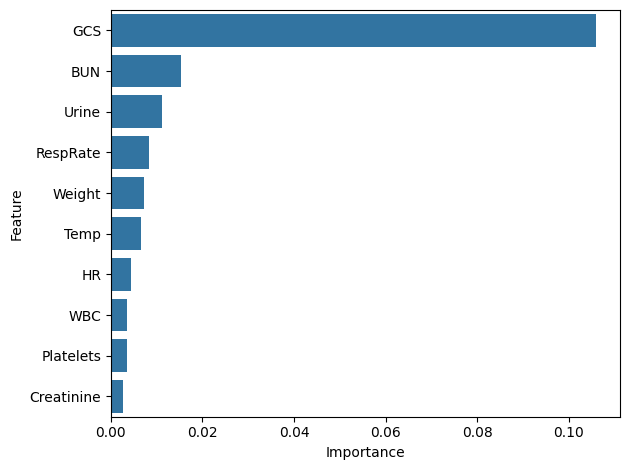

In [15]:
ep.ml.permutation_importance(edata, calibrated)
ep.pl.rank_features_supervised(edata, key="permutation_importance")

The Glasgow Coma Scale (GCS) dominates, followed by blood urea nitrogen (BUN) and urine output, in line with the neurological and renal components of severity scores such as SOFA.
Permutation importance measures what the model relies on, not causal effects, and correlated variables share their importance.

### Subgroups and fairness

A good average performance can hide subgroups for which a model works worse.
With `groupby`, {func}`~ehrapy.ml.evaluate` computes every metric per subgroup and their largest difference between subgroups.
The difference of `positive_rate` is the demographic parity difference, and `equalized_odds` is the larger difference of sensitivity and specificity.

In [16]:
by_age = ep.ml.evaluate(edata, task, key="calibrated", groupby="age_group", n_bootstrap=200)
ep.pl.subgroup_performance(by_age, metrics=["auroc", "calibration_slope", "sensitivity", "positive_rate"], width=350)

:Layout
   .Overlay.I   :Overlay
      .ErrorBars.I :ErrorBars   [age_group]   (auroc,lower,upper)
      .Scatter.I   :Scatter   [age_group]   (auroc)
   .Overlay.II  :Overlay
      .ErrorBars.I :ErrorBars   [age_group]   (calibration_slope,lower,upper)
      .Scatter.I   :Scatter   [age_group]   (calibration_slope)
   .Overlay.III :Overlay
      .ErrorBars.I :ErrorBars   [age_group]   (sensitivity,lower,upper)
      .Scatter.I   :Scatter   [age_group]   (sensitivity)
   .Overlay.IV  :Overlay
      .ErrorBars.I :ErrorBars   [age_group]   (positive_rate,lower,upper)
      .Scatter.I   :Scatter   [age_group]   (positive_rate)

The AUROC drops from 0.89 in patients under 65 to 0.79 in patients of 80 and older, whose predicted risks are also the least calibrated.
The model flags three times as many of the oldest patients, which partly reflects their higher mortality of 22% compared with 9%, so a demographic parity difference alone is no evidence of unfairness.

We compare these differences with those between women and men.

In [17]:
by_sex = ep.ml.evaluate(edata, task, key="calibrated", groupby="Gender", n_bootstrap=200)
pd.concat({"age group": by_age.loc["difference"], "sex": by_sex.loc["difference"]}, axis=1).round(3)

age group                      sex                  
                          value ci_lower ci_upper  value ci_lower ci_upper
metric                                                                    
auroc                     0.097    0.040    0.163  0.036   -0.008    0.084
auprc                     0.044   -0.111    0.187  0.003   -0.126    0.104
brier                     0.083    0.062    0.118  0.021    0.001    0.041
ece                       0.046    0.019    0.091  0.001   -0.019    0.026
calibration_intercept     0.089   -0.316    0.511  0.094   -0.222    0.382
calibration_slope         0.367    0.056    0.735  0.077   -0.143    0.304
sensitivity               0.036   -0.115    0.177  0.008   -0.103    0.105
specificity               0.046    0.022    0.073  0.003   -0.011    0.019
f1                        0.019   -0.148    0.180  0.003   -0.120    0.114
positive_rate             0.070    0.037    0.102  0.009   -0.011    0.031
equalized_odds            0.046    0.026    0.177  0.008   -0.007    0.105

Between women and men, discrimination and the share of flagged patients differ less: the AUROC by 0.04 and the share of flagged patients by less than one percentage point.
The confidence interval belongs to the difference between the two subgroups that are furthest apart, and between women and men it includes 0 for every metric except the Brier score.
Between age groups, the differences in AUROC, calibration slope and the share of flagged patients exclude 0, while metrics that rest on the few deaths per subgroup, such as sensitivity and AUPRC, are too uncertain to tell the age groups apart.

:::{important}
If the outcome is more common in one subgroup, a calibrated model cannot reach equal positive rates, sensitivities and specificities in all subgroups at once.
Which of these criteria matters depends on how the predictions are used, which is a clinical and ethical decision rather than a statistical one.
:::

:::{admonition} Detecting and mitigating bias
:class: tip
Leaving a sensitive variable out does not hide it from a model, and {func}`~ehrapy.preprocessing.detect_bias` finds the variables that can act as its proxies.
Where a model fails for a subgroup, first collect more of its patients, since subgroup-specific thresholds trade one fairness criterion for another.
:::

## Hourly sepsis prediction

In the PhysioNet 2019 data, `SepsisLabel` is a variable that is 1 from 6 hours before the onset of sepsis on, which turns it into an early warning.
A rolling task predicts it at every hour from the hours before, as a monitoring system would.
We load 10,000 of the 40,336 patients to keep this tutorial fast.

In [18]:
sepsis = ed.dt.physionet2019(n_samples=10_000)
sepsis

EHRData object with n_obs × n_vars × n_t = 10000 × 35 × 48
    obs: 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'training_Set'
    var: 'Parameter'
    tem: '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47'
    shape of .X: (10000, 35, 48)

The label varies over time, but the split needs one stratum per patient, so we stratify on whether a patient ever develops sepsis.

In [19]:
sepsis.obs["sepsis"] = np.nanmax(sepsis[:, "SepsisLabel"].X[:, 0, :], axis=1) == 1
ep.ml.split(sepsis, stratify="sepsis")

For a rolling task, gradient boosting is fit on the summaries of the last 6 hours at every labeled hour of the training patients.
The label itself is excluded from the features.

In [20]:
sepsis_task = ep.ml.Task("SepsisLabel", rolling=True, observation_window=6)
sepsis_model = ep.ml.fit(sepsis, sepsis_task, obs_keys=["Age", "Gender"], statistics=["mean", "last", "count", "slope"])
ep.ml.predict(sepsis, sepsis_model)

The evaluation pools every held-out patient-hour, and the bootstrap resamples patients with all their hours, since hours of the same patient are not independent.

In [21]:
held_out = sepsis[(sepsis.obs["split"] == "held_out").to_numpy(), "SepsisLabel"].X
print(f"Positive patient-hours: {np.nanmean(held_out):.1%}")
ep.ml.evaluate(sepsis, sepsis_task, n_bootstrap=200).round(3)

Positive patient-hours: 1.2%


,value,ci_lower,ci_upper
metric,,,
auroc,0.698,0.650,0.738
auprc,0.027,0.018,0.038
brier,0.013,0.010,0.016
ece,0.008,0.005,0.011
calibration_intercept,0.257,-0.044,0.514
calibration_slope,0.432,0.346,0.514
sensitivity,0.008,0.000,0.016
specificity,0.998,0.998,0.999
f1,0.014,0.000,0.029


In [22]:
ep.pl.prediction_performance(sepsis, sepsis_task)

:Layout
   .Overlay.I   :Overlay
      .Curve.I  :Curve   [False positive rate]   (True positive rate)
      .Curve.II :Curve   [False positive rate]   (True positive rate)
   .Overlay.II  :Overlay
      .Curve.I :Curve   [Recall]   (Precision)
      .HLine.I :HLine   [x,y]
   .Overlay.III :Overlay
      .Curve.I   :Curve   [Mean predicted probability]   (Observed frequency)
      .Scatter.I :Scatter   [x]   (y)
      .Curve.II  :Curve   [Mean predicted probability]   (Observed frequency)

Only 1.2% of the patient-hours are positive, which the AUROC of 0.70 hides, because it weighs every negative hour as much as the rare positive ones.

:::{important}
The AUPRC is the more honest number for rare labels, since its baseline is the prevalence: at 0.027, the model ranks about twice as well as guessing, yet most of its alarms would be false.
At a threshold of 0.5 almost no hour is flagged, so an early warning system needs a threshold chosen for an acceptable alarm rate.
:::

## Conclusion

ehrapy takes prediction from a patient-level split and a task with an observation window and gap to calibrated models with prediction sets, evaluated with patient-level bootstrap confidence intervals overall and per subgroup.
The same functions apply to summaries and raw time series, to built-in models and any PyTorch module such as SAITS, and to predictions at a single time or every hour.